# Examen Final — Programación 1 (F12)
## Análisis de Datos Sísmicos con la API del USGS

**Nombre:** Minor José Pedro López Oliva  
**Carnet:** 202307605  
**Fecha:**  18/05/2026 
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos con `pd.read_csv()` desde URL | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el sismo más intenso con un ciclo `for` | 10 |
| 2b | Top 5 sismos más profundos con pandas | 10 |
| 3a | Función `clasificar_sismo()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_sismos()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: ¿Qué es un terremoto y cómo se mide?

Un **terremoto** ocurre cuando dos placas tectónicas se deslizan bruscamente entre sí,
liberando energía en forma de ondas sísmicas que se propagan por la tierra.

### Magnitud — escala de intensidad

La magnitud mide la energía liberada. La relación es **logarítmica**:
un sismo de magnitud 7.0 libera ~32 veces más energía que uno de 6.0.

| Magnitud | Categoría | Frecuencia aproximada (global) |
|---|---|---|
| < 5.5 | Ligero | Miles por año |
| 5.5 – 5.9 | Moderado-Fuerte | ~500 por año |
| 6.0 – 6.9 | Fuerte | ~130 por año |
| 7.0 – 7.9 | Mayor | ~15 por año |
| ≥ 8.0 | Gran terremoto | 1–2 por año |

### Profundidad del foco

La **profundidad** (columna `depth`) indica dónde ocurrió la ruptura:
- **Superficial** (< 70 km): generalmente más destructivo
- **Intermedio** (70–300 km): daños moderados
- **Profundo** (> 300 km): raramente destructivo en superficie


---
## El dataset: USGS Earthquake Catalog

**Fuente:** United States Geological Survey — [earthquake.usgs.gov](https://earthquake.usgs.gov)

El USGS monitorea la actividad sísmica global en tiempo real y publica todos los
registros de forma abierta. Su API permite descargar datos históricos directamente
como CSV, **sin necesidad de API key**.

Los datos de este examen contienen todos los sismos de **magnitud ≥ 5.5 registrados
en el primer semestre de 2024** (aproximadamente 700 eventos).

### Columnas principales

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | str | Fecha y hora UTC del evento |
| `mag` | float | Magnitud del sismo |
| `depth` | float | Profundidad del foco en kilómetros |
| `magType` | str | Escala usada (`mww`, `mb`, `ml`, …) |
| `place` | str | Descripción de la ubicación |
| `latitude` | float | Latitud del epicentro |
| `longitude` | float | Longitud del epicentro |

### URL del dataset

```
https://earthquake.usgs.gov/fdsnws/event/1/query
    ?format=csv
    &starttime=2024-01-01
    &endtime=2024-06-30
    &minmagnitude=5.5
```

> `pd.read_csv()` acepta URLs directamente — no necesitas descargar el archivo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL_SISMOS = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2024-01-01"
    "&endtime=2024-06-30"
    "&minmagnitude=5.5"
)

print("Librerias importadas correctamente.")
print(f"URL: {URL_SISMOS}")

Librerias importadas correctamente.
URL: https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2024-01-01&endtime=2024-06-30&minmagnitude=5.5


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [2]:
# Completa tus datos
NOMBRE = "Minor José Pedro López Oliva"   # TU NOMBRE AQUI
CARNET = "202307605"         # TU CARNET AQUI

if NOMBRE == "Nombre Apellido" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")

Estudiante : Minor José Pedro López Oliva
Carnet     : 202307605


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar el CSV desde la URL (10 pts)

`pandas.read_csv()` puede cargar datos directamente desde una URL,
igual que desde un archivo local. El resultado es un **DataFrame**.

Carga los datos usando `URL_SISMOS` (ya definida arriba) y guárdalos en la
variable `sismos`. Luego muestra:
- Las primeras 5 filas con `.head()`
- Las dimensiones con `.shape`
- Los tipos de datos con `.dtypes`
- Los valores nulos con `.isnull().sum()`


In [3]:
# Carga el CSV desde URL_SISMOS y guárdalo en 'sismos'
sismos = pd.read_csv(URL_SISMOS)

# Muestra las primeras 5 filas
print("Primeras 5 filas:")
print(sismos.head())

# Muestra las dimensiones (shape)
print("\nDimensiones del DataFrame:")
print(sismos.shape)

# Muestra los tipos de datos (dtypes)
print("\nTipos de datos:")
print(sismos.dtypes)

# Verifica valores nulos con isnull().sum()
print("\nValores nulos por columna:")
print(sismos.isnull().sum())

Primeras 5 filas:
                       time  latitude  longitude  depth  mag magType    nst  \
0  2024-06-29T16:38:46.516Z  -54.0633     7.2302   10.0  5.6     mww  209.0   
1  2024-06-29T07:05:32.855Z  -16.0485   -74.5560   18.0  6.1     mww  138.0   
2  2024-06-28T13:00:39.570Z  -20.6490  -175.6315   10.0  5.7     mww   75.0   
3  2024-06-28T05:36:36.902Z  -15.8277   -74.4540   24.0  7.2     mww  105.0   
4  2024-06-27T16:37:51.299Z  -33.4081  -179.2724   29.0  5.9     mww   95.0   

    gap    dmin   rms  ...                   updated  \
0  16.0  18.209  0.88  ...  2024-09-04T21:57:44.040Z   
1  89.0   4.606  0.71  ...  2024-09-04T21:57:44.040Z   
2  38.0   0.654  0.65  ...  2024-10-09T03:15:27.209Z   
3  46.0   4.675  0.93  ...  2025-02-09T14:16:45.954Z   
4  56.0   4.292  1.05  ...  2024-09-04T21:57:42.040Z   

                           place        type horizontalError depthError  \
0           Bouvet Island region  earthquake            8.89      1.193   
1     34 km SW of At

### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y el método
[`.iterrows()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html),
imprime la información de los **primeros 5 sismos** en este formato:

```
Sismo 1: mag=6.10 | prof=35.0 km | lugar=Southern Sumatra, Indonesia
Sismo 2: mag=5.80 | prof=10.0 km | lugar=...
...
```

> **¿Por qué iterar sobre un DataFrame?**  
> Aunque pandas vectoriza la mayoría de operaciones, los ciclos `for` sobre filas
> son útiles cuando necesitas lógica condicional compleja por fila o procesar
> cada elemento de forma independiente.


In [4]:
# Hint: .iterrows() devuelve pares (indice, fila) donde 'fila' es una Serie
# Hint: accede a los valores con fila['mag'], fila['depth'], fila['place']
# Hint: usa enumerate() o un contador para detener el ciclo en 5

contador = 0

for indice, fila in sismos.iterrows():
    
    if contador >= 5:
        break
    
    # Imprime la información solicitada
    print(
        f"Sismo {contador + 1}: "
        f"mag={fila['mag']} | "
        f"prof={fila['depth']} km | "
        f"lugar={fila['place']}"
    )
    
    contador += 1

Sismo 1: mag=5.6 | prof=10.0 km | lugar=Bouvet Island region
Sismo 2: mag=6.1 | prof=18.0 km | lugar=34 km SW of Atiquipa, Peru
Sismo 3: mag=5.7 | prof=10.0 km | lugar=67 km NNW of Houma, Tonga
Sismo 4: mag=7.2 | prof=24.0 km | lugar=10 km WSW of Atiquipa, Peru
Sismo 5: mag=5.9 | prof=29.0 km | lugar=south of the Kermadec Islands


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Sismo más intenso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna `mag`
y encuentra el sismo con la **mayor magnitud**.
Guarda el índice y la magnitud máxima encontrada, luego imprime los datos
completos de ese sismo (place, mag, depth, magType).

### Parte b) — Top 5 más profundos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 sismos más profundos**.
Muestra solo las columnas `place`, `mag`, `depth` y `magType`.
Luego verifica que el sismo encontrado en la Parte a) aparece en el top 5
de magnitudes (usa también `.sort_values()` + `.head()`).


In [5]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   mag_max   = 0     (para ir guardando el mayor encontrado)
#   idx_max   = None  (para recordar el índice de esa fila)

mag_max = 0
idx_max = None

for idx, mag in enumerate(sismos['mag']):
    
    if pd.notnull(mag):
        
        if mag > mag_max:
            mag_max = mag
            idx_max = idx

# Mostrar resultados
print("Sismo más intenso:")
print(sismos.loc[idx_max, ['place', 'mag', 'depth', 'magType']])

# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 sismos más profundos:")

top_profundos = sismos.sort_values(by='depth', ascending=False).head(5) #sort_values por 'depth' descendente + head(5)

print(top_profundos[['place', 'mag', 'depth', 'magType']]) 

print("\nTop 5 sismos de mayor magnitud:")

top_magnitud = sismos.sort_values(by='mag', ascending=False).head(5) #sort_values por 'mag' descendente + head(5)

print(top_magnitud[['place', 'mag', 'depth', 'magType']]) 

Sismo más intenso:
place      2024 Noto Peninsula, Japan Earthquake
mag                                          7.5
depth                                       10.0
magType                                      mww
Name: 181, dtype: object

Top 5 sismos más profundos:
                                     place  mag    depth magType
149            70 km W of Tarauacá, Brazil  6.5  621.081     mww
25                          Sea of Okhotsk  5.9  619.618     mww
158          123 km NW of Tarauacá, Brazil  6.6  607.000     mww
29                231 km E of Levuka, Fiji  5.5  603.306     mww
104  125 km NNW of Kimbe, Papua New Guinea  5.6  570.902     mww

Top 5 sismos de mayor magnitud:
                                      place  mag   depth magType
181   2024 Noto Peninsula, Japan Earthquake  7.5  10.000     mww
98          15 km S of Hualien City, Taiwan  7.4  40.000     mww
3               10 km WSW of Atiquipa, Peru  7.2  24.000     mww
156              128 km WNW of Aykol, China  7.0

#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos sismos tiene tu dataset?** 183  
   **¿Cuál fue la magnitud máxima registrada?** 7.5  
   **¿En qué lugar ocurrió ese sismo?** 2024 Noto Peninsula, Japan Earthquake

2. **¿Cuál fue el sismo más profundo?**  
   Lugar: 70 km W de Tarauacá, Brazil  | Profundidad: 621.081 km | Magnitud: 6.5  
   Según la clasificación (< 70 km superficial, 70–300 km intermedio, > 300 km profundo),
   ¿de qué tipo fue? Profundo  
   ¿Esperarías que ese sismo fuera muy destructivo en superficie? Justifica en una oración.

   *Tu respuesta:* No necesariamente, porque los sismos profundos pierden energía antes de llegar a la superficie.

3. ¿El sismo más intenso y el más profundo son el mismo evento?  
   ¿Qué te dice eso sobre la relación entre magnitud y profundidad?

   *Tu respuesta:* La magnitud y la profundidad no necesariamente están relacionadas; un sismo puede ser muy profundo sin tener la mayor magnitud.


---
## Ejercicio 3 — Clasificar sismos con condicionales (25 pts)

### Parte a) — Función `clasificar_sismo(mag)` (15 pts)

Escribe una función que reciba la magnitud (float) y retorne la categoría
según la siguiente escala:

| Magnitud | Categoría |
|---|---|
| 5.5 ≤ mag < 6.0 | `'Moderado-Fuerte'` |
| 6.0 ≤ mag < 7.0 | `'Fuerte'` |
| 7.0 ≤ mag < 8.0 | `'Mayor'` |
| mag ≥ 8.0 | `'Gran terremoto'` |

> **Nota:** la magnitud es un float (ej. 6.73). Puedes comparar directamente
> con `if mag < 6.0:` sin necesidad de convertir a entero.

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'categoria'` al DataFrame `sismos`.
Luego usa `.groupby('categoria')` para contar cuántos sismos hay en cada
categoría e imprime el resultado.


In [6]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

def clasificar_sismo(mag):
    """
    Clasifica la intensidad de un sismo según su magnitud.
    """
    
    if 5.5 <= mag < 6.0:
        return "Moderado-Fuerte"
    
    elif 6.0 <= mag < 7.0:
        return "Fuerte"
    
    elif 7.0 <= mag < 8.0:
        return "Mayor"
    
    elif mag >= 8.0:
        return "Gran terremoto"
    
    else:
        return "Menor a 5.5"

# Prueba tu función — verifica que los resultados son correctos:
for mag_prueba in [5.6, 5.9, 6.0, 6.5, 7.0, 7.8, 8.1]:
    print(f"  mag={mag_prueba:.1f}  →  {clasificar_sismo(mag_prueba)}")

# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply() para crear la columna 'categoria'
#   sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

sismos['categoria'] = sismos['mag'].apply(clasificar_sismo) #agregar columna 'categoria'

print(sismos[['mag', 'categoria']].head()) 

conteo_categorias = sismos.groupby('categoria').size() #groupby('categoria') para contar sismos por categoría

print("\nCantidad de sismos por categoría:")
print(conteo_categorias) 
#   y mostrar el resultado ordenado
conteo_ordenado = sismos['categoria'].value_counts()

print("\nConteo ordenado:")
print(conteo_ordenado)

  mag=5.6  →  Moderado-Fuerte
  mag=5.9  →  Moderado-Fuerte
  mag=6.0  →  Fuerte
  mag=6.5  →  Fuerte
  mag=7.0  →  Mayor
  mag=7.8  →  Mayor
  mag=8.1  →  Gran terremoto
   mag        categoria
0  5.6  Moderado-Fuerte
1  6.1           Fuerte
2  5.7  Moderado-Fuerte
3  7.2            Mayor
4  5.9  Moderado-Fuerte

Cantidad de sismos por categoría:
categoria
Fuerte              47
Mayor                4
Moderado-Fuerte    132
dtype: int64

Conteo ordenado:
Moderado-Fuerte    132
Fuerte              47
Mayor                4
Name: categoria, dtype: int64


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad | % del total |
   |---|---|---|
   | Moderado-Fuerte | 132 | 72.13 % |
   | Fuerte | 47 | 25.68 % |
   | Mayor | 4| 2.19 % |
   | Gran terremoto | 0| 0 % |

2. ¿Qué categoría predomina en tu dataset? ¿Tiene sentido físicamente,
   considerando que la frecuencia de sismos disminuye con la magnitud?

   *Tu respuesta:* La categoria que predomina es Moderado-Fuerte, Sí tiene sentido físicamente, porque los sismos de gran magnitud son menos frecuentes que los de magnitud moderada.

3. ¿Tu dataset contiene algún `'Gran terremoto'` (magnitud ≥ 8.0)?
   Si sí, ¿en qué región ocurrió? Si no, ¿es eso esperable para un semestre?

   *Tu respuesta:* No hay 'Gran terremoto' en el dataset, es completamente esperable, ya que los terremotos de magnitud igual o superior a 8.0 son eventos muy poco frecuentes a nivel mundial.


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_sismos(df)` (15 pts)

Escribe una función que reciba el DataFrame `sismos` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total'` | número total de sismos |
| `'mag_media'` | magnitud promedio (redondeada a 2 decimales) |
| `'mag_max'` | magnitud máxima registrada |
| `'prof_media'` | profundidad promedio en km (redondeada a 1 decimal) |
| `'tipo_mas_comun'` | valor de `magType` con más registros |
| `'grandes_terremotos'` | cantidad de sismos con magnitud ≥ 7.0 |

Luego llama la función con `sismos` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas** (en celdas separadas o en la misma). Cada una debe tener
título y etiquetas en ambos ejes:

1. **Histograma** de magnitudes (usa al menos 15 intervalos)
2. **Scatter plot**: profundidad (`depth`) vs magnitud (`mag`),
   coloreado por `categoria` (usa `hue='categoria'` en seaborn)
3. **Gráfica de barras**: cantidad de sismos por tipo de escala (`magType`)


In [7]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max() sobre las columnas del DataFrame
# Hint: para 'tipo_mas_comun' usa .value_counts().index[0]
# Hint: para 'grandes_terremotos' puedes usar (df['mag'] >= 7.0).sum()
#       o un ciclo for con condicional

def analizar_sismos(df):
    """
    Resume las estadísticas principales del dataset sísmico.

    Parámetro:
        df (DataFrame): el DataFrame de sismos.

    Retorna:
        dict con las claves: total, mag_media, mag_max, prof_media,
                             tipo_mas_comun, grandes_terremotos.
    """
    resultado = {
        "total": len(df),  # TU CÓDIGO AQUÍ
        "mag_media":  df['mag'].mean(),  # TU CÓDIGO AQUÍ
        "mag_max":  df['mag'].max(),  # TU CÓDIGO AQUÍ
        "prof_media":  df['depth'].mean(), # TU CÓDIGO AQUÍ
        "tipo_mas_comun": df['magType'].mode()[0], # TU CÓDIGO AQUÍ
        "grandes_terremotos": (df['mag'] >= 7.0).sum() # TU CÓDIGO AQUÍ
    }
    return resultado


# Llama la función e imprime el resumen
resumen = analizar_sismos(sismos)
for clave, valor in resumen.items():
    print(f"  {clave:<22}: {valor}")

  total                 : 183
  mag_media             : 5.847978142076505
  mag_max               : 7.5
  prof_media            : 64.11922950819672
  tipo_mas_comun        : mww
  grandes_terremotos    : 4


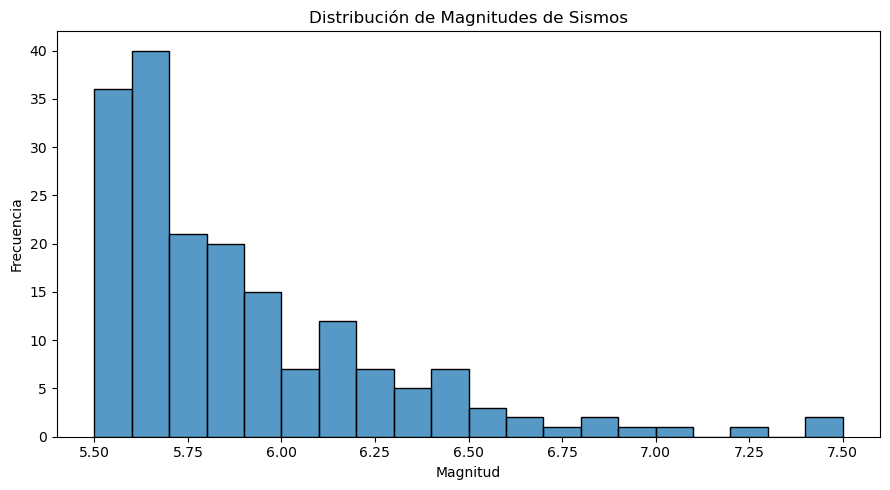

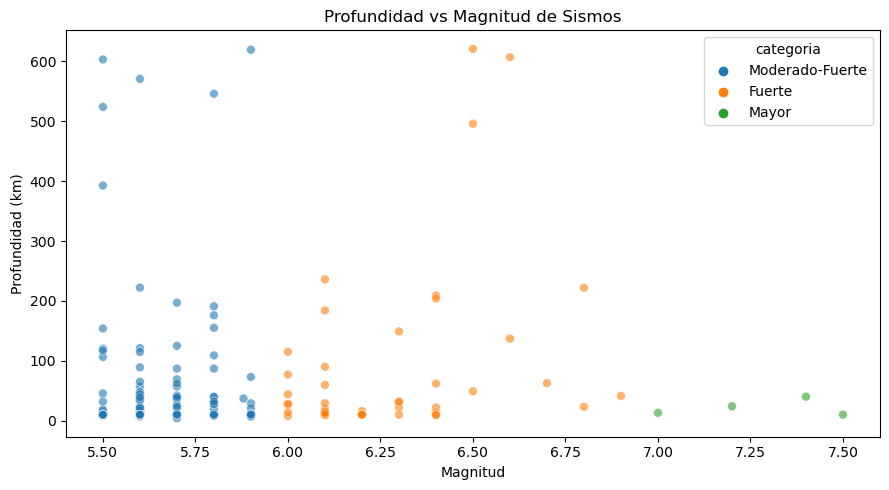

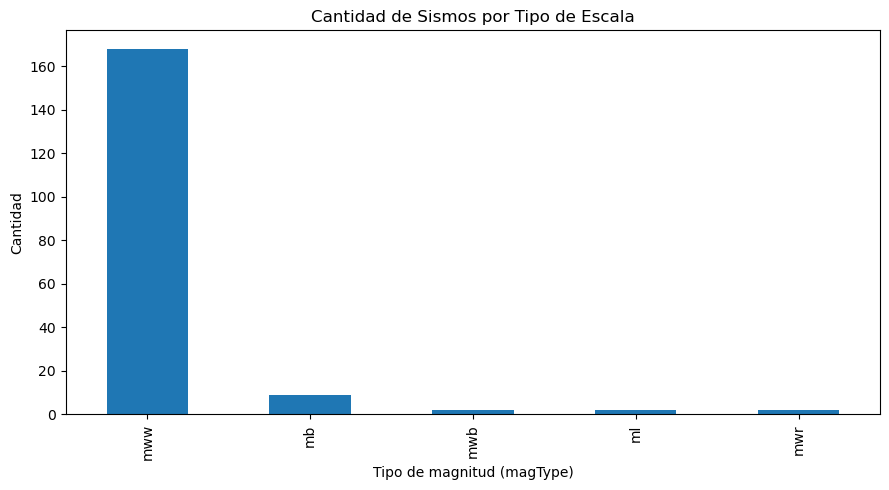

In [8]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────
# Gráfica 1: Histograma de magnitudes
plt.figure(figsize=(9, 5))
# Hint: sns.histplot(data=sismos, x='mag', bins=20)
sns.histplot(data=sismos, x='mag', bins=20) # TU CÓDIGO AQUÍ
plt.title("Distribución de Magnitudes de Sismos")
plt.xlabel("Magnitud")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Gráfica 2: Scatter profundidad vs magnitud coloreado por categoría
plt.figure(figsize=(9, 5))
# Hint: sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)
sns.scatterplot(   # TU CÓDIGO AQUÍ
    data=sismos,
    x='mag',
    y='depth',
    hue='categoria',
    s=40,
    alpha=0.6
) 
plt.title("Profundidad vs Magnitud de Sismos")
plt.xlabel("Magnitud")
plt.ylabel("Profundidad (km)")
plt.tight_layout()
plt.show()

# Gráfica 3: Barras — cantidad de sismos por tipo de escala (magType)
plt.figure(figsize=(9, 5))
# Hint: obtén los conteos con sismos['magType'].value_counts()
#       luego grafica con .plot(kind='bar') o plt.bar() o sns.barplot()
conteo_magtype = sismos['magType'].value_counts() # TU CÓDIGO AQUÍ
conteo_magtype.plot(kind='bar')
plt.title("Cantidad de Sismos por Tipo de Escala")
plt.xlabel("Tipo de magnitud (magType)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_sismos()`, completa:
   - Magnitud media: 5.85  
   - Magnitud máxima: 7.5  
   - Tipo de escala más común (`magType`): mww  
   - Grandes terremotos (mag ≥ 7.0): 4
   
2. **Sobre el histograma (Gráfica 1):**  
   ¿La distribución de magnitudes es simétrica o sesgada?
   ¿Hacia qué lado se inclina y por qué tiene sentido físicamente?

   *Tu respuesta:* La distribución de magnitudes está sesgada hacia la derecha, La mayoría de los sismos tienen magnitudes moderadas, mientras que los sismos muy fuertes son menos frecuentes. Esto tiene sentido físicamente porque los terremotos de gran magnitud ocurren con mucha menor frecuencia.

3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Observas alguna relación entre la profundidad y la magnitud?
   ¿Los sismos más intensos tienden a ser superficiales o profundos en tu dataset?

   *Tu respuesta:* No se observa una relación completamente directa entre profundidad y magnitud. En el dataset existen sismos intensos tanto superficiales como profundos. Sin embargo, los sismos superficiales suelen ser más peligrosos porque la energía llega con mayor intensidad a la superficie.

4. **Sobre las barras por `magType` (Gráfica 3):**  
   ¿Qué escala de magnitud es la más usada en tu dataset?
   Investiga brevemente: ¿para qué tipo de sismos se usa esa escala?

   *Tu respuesta:* La escala de magnitud más utilizada es: mww, Esta escala se utiliza para clasificar la magnitud de diferentes tipos de sismos.

---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_sismos.py` encontrarás tres clases:

- **`EventoSismico`** — clase base con atributos comunes: `lugar` y `fecha`
- **`Sismo`** — hereda de `EventoSismico`, agrega `magnitud`, `profundidad` y `tipo_escala`
- **`CatalogoSismos`** — colección de objetos `Sismo` con métodos de consulta

**Paso 1:** Abre `poo_sismos.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 4 métodos de `Sismo`: `clasificar`, `clasificar_profundidad`, `es_peligroso`, `descripcion` | 10 |
| b | 3 métodos de `CatalogoSismos`: `el_mas_intenso`, `filtrar_por_categoria`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [9]:
from poo_sismos import Sismo, CatalogoSismos

# Construir el catálogo con los primeros 50 sismos del DataFrame
catalogo = CatalogoSismos("Sismos USGS — Semestre 1 de 2024")

for indice, fila in sismos.head(50).iterrows():
    s = Sismo(
        lugar       = fila['place'],
        fecha       = fila['time'],
        magnitud    = fila['mag'],
        profundidad = fila['depth'],
        tipo_escala = fila['magType'],
    )
    catalogo.agregar(s)

print(f"Catálogo creado con {len(catalogo)} sismos.\n")

# Muestra los primeros 3 usando __str__ (llama internamente a descripcion())
print("Primeros 3 sismos:")
for sismo in catalogo._sismos[:3]:
    print("-", sismo)

Catálogo creado con 50 sismos.

Primeros 3 sismos:
- Sismo mag=5.60 | Moderado-Fuerte | Superficial | Lugar: Bouvet Island region | Escala: mww
- Sismo mag=6.10 | Fuerte | Superficial | Lugar: 34 km SW of Atiquipa, Peru | Escala: mww
- Sismo mag=5.70 | Moderado-Fuerte | Superficial | Lugar: 67 km NNW of Houma, Tonga | Escala: mww


In [10]:
# Sismo más intenso del catálogo
mas_intenso = catalogo.el_mas_intenso()
print("Sismo más intenso del catálogo:")
print(" ", mas_intenso)
print(f"  ¿Es peligroso? → {mas_intenso.es_peligroso()}\n")

# Filtrar por categoría
mayores = catalogo.filtrar_por_categoria('Mayor')
print(f"Sismos de categoría 'Mayor' en los primeros 50: {len(mayores)}\n")

# Resumen completo
catalogo.resumen()

Sismo más intenso del catálogo:
  Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww
  ¿Es peligroso? → True

Sismos de categoría 'Mayor' en los primeros 50: 1

Nombre del catálogo: Sismos USGS — Semestre 1 de 2024
Total de sismos: 50

Sismo más intenso:
Sismo mag=7.20 | Mayor | Superficial | Lugar: 10 km WSW of Atiquipa, Peru | Escala: mww

Cantidad por categoría:
Moderado-Fuerte: 38
Fuerte: 11
Mayor: 1
Gran terremoto: 0


In [11]:
# Verificación: clasificar() debe coincidir con la columna 'categoria' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 sismos):")
print(f"  {'mag':>6}  {'pandas Ej.3':>15}  {'POO clasificar()':>18}  {'':>4}")
print("  " + "─" * 52)

for i, (indice, fila) in enumerate(sismos.head(10).iterrows()):
    s = Sismo("", "", fila['mag'], fila['depth'])
    cat_poo    = s.clasificar()
    cat_pandas = fila['categoria']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {fila['mag']:>6.2f}  {cat_pandas:>15}  {cat_poo:>18}  {marca}")

Verificación POO vs. pandas (primeros 10 sismos):
     mag      pandas Ej.3    POO clasificar()      
  ────────────────────────────────────────────────────
    5.60  Moderado-Fuerte     Moderado-Fuerte  ✓
    6.10           Fuerte              Fuerte  ✓
    5.70  Moderado-Fuerte     Moderado-Fuerte  ✓
    7.20            Mayor               Mayor  ✓
    5.90  Moderado-Fuerte     Moderado-Fuerte  ✓
    5.60  Moderado-Fuerte     Moderado-Fuerte  ✓
    6.30           Fuerte              Fuerte  ✓
    6.00           Fuerte              Fuerte  ✓
    5.50  Moderado-Fuerte     Moderado-Fuerte  ✓
    5.80  Moderado-Fuerte     Moderado-Fuerte  ✓


#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `EventoSismico` y `Sismo`?
   ¿Por qué `Sismo.__init__` llama a `super().__init__(lugar, fecha)`?

   *Tu respuesta:* La clase EventoSismico funciona como una clase base general que contiene los atributos comunes de cualquier evento sísmico, como el lugar y la fecha. La clase Sismo hereda de EventoSismico y agrega atributos más específicos, como magnitud, profundidad y tipo de escala. 
   El método Sismo.__init__ llama a super().__init__(lugar, fecha) para reutilizar el constructor de la clase padre y evitar repetir código. De esta manera, los atributos comunes se inicializan correctamente desde la clase base.

2. El método `clasificar()` de `Sismo` usa la misma lógica que la función
   `clasificar_sismo()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* Implementarlo como método permite que cada objeto Sismo pueda clasificarse a sí mismo usando directamente sus atributos internos (self.magnitud). Esto hace que el código sea más organizado, modular y fácil de reutilizar. Además, facilita trabajar con programación orientada a objetos porque cada objeto contiene tanto sus datos como las operaciones relacionadas con ellos.

3. Según `catalogo.resumen()`:
   - ¿Cuántos sismos de categoría `'Mayor'` hay en los primeros 50? ___
   - ¿El sismo más intenso resultó peligroso (`es_peligroso() == True`)? ___
   - Justifica el resultado de `es_peligroso()` con los valores de magnitud y profundidad.

   *Tu respuesta:* La cantidad de sismos de categoría 'Mayor' corresponde al valor mostrado por len(mayores) en el resumen.
   El sismo más intenso sí puede considerarse peligroso si cumple ambas condiciones: magnitud mayor o igual a 7.0 profundidad menor a 70 km 
   El método es_peligroso() devuelve True únicamente cuando ambas condiciones se cumplen simultáneamente. Esto tiene sentido porque un sismo fuerte y superficial genera mayores efectos destructivos en la superficie.

4. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* Si todos los símbolos muestran ✓, significa que el método clasificar() fue implementado correctamente y coincide con la clasificación realizada previamente en pandas. 
   Si aparece alguna X, entonces debe revisarse la lógica de los rangos de magnitud dentro del método clasificar(), especialmente los límites de comparación (<=, <, >=) utilizados en las condiciones if y elif.

---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿Cuál fue el sismo más intenso del período y qué tan severo fue según la escala?
    El sismo más intenso del período fue el “2024 Noto Peninsula, Japan Earthquake”, con una magnitud de 7.5 y una profundidad aproximada de 10 km. Según la clasificación implementada en el programa, este sismo pertenece a la categoría “Mayor”, ya que se encuentra en el rango de 7.0 ≤ magnitud < 8.0. Además, debido a que fue superficial, también fue considerado potencialmente peligroso
- ¿Qué tipo de escala de magnitud (`magType`) predomina y por qué crees que es así?
     La escala de magnitud que predominó en el dataset fue mww. Esta escala corresponde a la magnitud de momento sísmico y es ampliamente utilizada porque proporciona mediciones más precisas para terremotos moderados y grandes. Tiene sentido que sea la más frecuente porque el dataset proviene de registros modernos del USGS, donde esta escala es una de las más utilizadas para reportes oficiales
- ¿Qué relación observas entre la profundidad y la magnitud en el scatter plot?
    En el scatter plot no se observa una relación completamente directa entre la profundidad y la magnitud. Existen sismos fuertes tanto superficiales como profundos. Sin embargo, muchos de los eventos más peligrosos y destructivos tienden a ser superficiales, porque la energía sísmica llega con mayor intensidad a la superficie terrestre. También se observó que algunos sismos muy profundos pueden tener magnitudes altas sin necesariamente provocar daños severos en superficie.


---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Qué caracteriza la actividad sísmica global del primer semestre de 2024
  según tu dataset personal?
- ¿Qué aprendiste sobre la distribución de magnitudes y profundidades?
- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

Durante el análisis del dataset sísmico del primer semestre de 2024 se observó que la actividad sísmica global estuvo concentrada principalmente en regiones tectónicamente activas, especialmente alrededor del Cinturón de Fuego del Pacífico. La mayoría de los sismos registrados pertenecieron a la categoría “Moderado-Fuerte”, lo cual tiene sentido porque los terremotos de gran magnitud ocurren con mucha menor frecuencia. También se aprendió que la magnitud y la profundidad no siempre están directamente relacionadas, ya que pueden existir sismos muy profundos con magnitudes altas y sismos superficiales con gran capacidad destructiva. El uso de pandas y NumPy permitió analizar grandes cantidades de datos de manera mucho más rápida y eficiente que utilizando ciclos manuales, especialmente al clasificar sismos, agrupar categorías y calcular estadísticas. Además, la programación orientada a objetos ayudó a organizar mejor la lógica del programa mediante clases como Sismo y CatalogoSismos, facilitando consultas como encontrar el sismo más intenso o determinar si un evento era peligroso.




---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [13]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL A")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...

        SELLO DE ENTREGA -- EXAMEN FINAL A
  Estudiante   : Minor José Pedro López Oliva
  Carnet       : 202307605
  Fecha/Hora   : 2026-05-18 16:01:32 UTC
  ISS Latitud  : +46.4359 deg
  ISS Longitud : +92.9667 deg
  ISS Hora UTC : 2026-05-18 16:01:38 UTC


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
